# Model Starts Notebook

This notebook will be used to train and evaluate an XGBoost and Random Forest models. The Random Forest model will first be run without being corrected, and then run after preprocessing to compare the results.

In the notebook you will find the below:

1. [Data and EDA](#read-in-data-and-eda)
2. [Setting up the model](#setting-up-the-model)
3. [Baseline model](#baseline-model)
4. [Hyperparameter tuning](#hyperparameter-tuning)
5. [Comparing the results](#results-comparison)

Read in the necessary libraries:

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_squared_error
import seaborn as sns
import warnings

**Needed Function Definitions**

In [147]:
#helper functions 
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0].keys()

# data cleaning functions
def find_bad_storms(df, na_columns):
    # find storms where ALL values are null for any of the cols
    bad_storms = []
    for storm in df['typhoon_name'].unique():
        for col in na_columns:
            if df[df['typhoon_name'] == storm][col].isna().all():
                bad_storms.append(storm)
                break  # no need to check other cols

    bad_storms = list(set(bad_storms))
    return bad_storms

def calculate_storm_medians(df, cols):
    '''
    This function will calculate storm-specific medians for the affected cells and creates a dictionary
    so we can do this for the test set as well.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            prob_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 1)][col].median()
            not_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 0)][col].median()
            overall_median = df[df['typhoon_name'] == storm][col].median()

            storm_medians[storm][col] = {
                'prob_aff': prob_median,
                'not_affected': not_median,
                'overall_median': overall_median
            }
    return storm_medians

def get_storm_median_for_row(row, storm_medians, col):
    '''
    This function will get the storm-specific medians for a given row, and will check if the s
    '''
    storm_name = row['typhoon_name']
    
    # fallback if storm not seen during training
    if storm_name not in storm_medians:
        return np.nan  # or a global median you pass in
    
    medians = storm_medians[storm_name][col]
    
    if row['prob_aff'] == 1 and not pd.isna(medians['prob_aff']):
        return medians['prob_aff']
    elif row['prob_aff'] == 0 and not pd.isna(medians['not_affected']):
        return medians['not_affected']
    else:
        return medians['overall_median']

def drop_correlated_features(X_train,y_train,method='spearman'):
    corr_cols_to_drop = []
    cols_to_skip = []
    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > 0.75:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop


### Read in data and EDA

In [53]:
# 'percent_houses_damaged','percent_houses_damaged_5years'
df = pd.read_csv('../data/target/model_training_data_new.csv')
y_1 = df[['percent_houses_damaged']]
y_2 = df[['percent_houses_damaged_5years']]
X = df.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

Look into the correlation and distribution of the columns that we currently have. Determine what to do with our NA values. We'll need to handle these, but they will all need to be dealt with.

Look into:
- Heteroscedasticity
- Correlation/multicollinearity
- Distribution and outliers
- class imbalace for the affected cells

In [117]:
df

,typhoon_name,typhoon_year,grid_point_id,percent_houses_damaged,percent_houses_damaged_5years,prop_NODATA_VALUE_aff,prop_not_enough_data_aff,majority_aff,minority_aff,prop_NODATA_VALUE_available,...,mean_recov_dur_pers_avail30,median_recov_dur_pers_avail30,prop_NODATA_VALUE_sd,prop_not_enough_data_sd,mean_sd,median_sd,affected_perc,cert_aff,prob_aff,cert_not_aff
0,BOPHA,2012,101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,BOPHA,2012,4475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BOPHA,2012,4639,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BOPHA,2012,4640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,BOPHA,2012,4641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28971,MANGKHUT,2018,20677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28972,MANGKHUT,2018,20678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28973,MANGKHUT,2018,20679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28974,MANGKHUT,2018,20680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [87]:
# DP_cols = [col for col in df.columns if 'DP' in col]

# df[['prop_NODATA_VALUE_DPmax']].value_counts()

cols_to_check = [
    'prop_NODATA_VALUE_DPmax',
    'prop_NODATA_VALUE_pre_event_mean',
    'prop_NODATA_VALUE_impact_dur_avail50',
    'prop_NODATA_VALUE_impact_dur_pers_avail50',
    'prop_NODATA_VALUE_impact_dur_avail30',
    'prop_NODATA_VALUE_impact_dur_pers_avail30',
    'prop_NODATA_VALUE_preevent_avail',
    'prop_NODATA_VALUE_recov_dur_avail50',
    'prop_NODATA_VALUE_recov_dur_avail30',
    'prop_NODATA_VALUE_recov_dur_pers_avail50',
    'prop_NODATA_VALUE_recov_dur_pers_avail30',
    'prop_not_enough_data_DPmax',
    'prop_not_enough_data_pre_event_mean',
    'prop_not_enough_data_impact_dur_avail50',
    'prop_not_enough_data_impact_dur_pers_avail50',
    'prop_not_enough_data_impact_dur_avail30',
    'prop_not_enough_data_impact_dur_pers_avail30',
    'prop_not_enough_data_preevent_avail',
    'prop_not_enough_data_recov_dur_avail50',
    'prop_not_enough_data_recov_dur_avail30',
    'prop_not_enough_data_recov_dur_pers_avail50',
    'prop_not_enough_data_recov_dur_pers_avail30',
]

df[cols_to_check[:10]].describe()

,prop_NODATA_VALUE_DPmax,prop_NODATA_VALUE_pre_event_mean,prop_NODATA_VALUE_impact_dur_avail50,prop_NODATA_VALUE_impact_dur_pers_avail50,prop_NODATA_VALUE_impact_dur_avail30,prop_NODATA_VALUE_impact_dur_pers_avail30,prop_NODATA_VALUE_preevent_avail,prop_NODATA_VALUE_recov_dur_avail50,prop_NODATA_VALUE_recov_dur_avail30,prop_NODATA_VALUE_recov_dur_pers_avail50
count,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000
mean,0.835881,0.752105,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792
std,0.370355,0.431738,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
nas_finder = df.isna().sum()

In [9]:
nas_finder[nas_finder > 0].to_csv('../data/nas_finder_new_2.csv')

In [10]:
nas_finder[nas_finder > 0].describe()

# 21541/28976, 28590/28976
# (0.7434083379348426, 0.9866786305908338)

count       24.000000
mean     23720.000000
std       7633.405474
min       1147.000000
25%      21495.250000
50%      26725.000000
75%      28590.000000
max      28590.000000
dtype: float64

In [11]:
nas_finder

typhoon_name                     0
typhoon_year                     0
grid_point_id                    0
percent_houses_damaged           0
percent_houses_damaged_5years    0
                                ..
affected_perc                    0
cert_aff                         0
prob_aff                         0
cert_not_aff                     0
cert_not_aff_perc                0
Length: 66, dtype: int64

In [12]:
# since we're going to imput values for the nulls for the random forest model
# we are making a column to get if the value was originally null or not
# hopefully this will help the model to learn that some values were imputed and not real values
#  which could be useful for the model to learn patterns in the data

for i in nas_finder[nas_finder > 0].keys():
    new_col = f'{i}_isna'
    df[new_col] = df[i].isna().astype(int)

In [13]:
#checking to see if there are nulls where prob_aff is 1, which means that the cell is probably affected by the typhoon
# if so we'll fill the nulls with the median value of the column, but we want to see how many nulls there are first
aff_cols = [col for col in df.columns if 'aff' in col]
na_cols = nas_finder[nas_finder > 0].keys()

df[df['prob_aff'] == 1][na_cols].isna().sum()

mean_DPmax                           0
median_DPmax                         0
mean_pre_event_mean                  0
median_pre_event_mean                0
mean_impact_dur_avail50           4080
median_impact_dur_avail50         4080
mean_impact_dur_pers_avail50      4080
median_impact_dur_pers_avail50    4080
mean_impact_dur_avail30           2215
median_impact_dur_avail30         2215
mean_impact_dur_pers_avail30      2215
median_impact_dur_pers_avail30    2215
mean_preevent_avail                  0
median_preevent_avail                0
mean_recov_dur_avail50            4080
median_recov_dur_avail50          4080
mean_recov_dur_avail30            2215
median_recov_dur_avail30          2215
mean_recov_dur_pers_avail50       4080
median_recov_dur_pers_avail50     4080
mean_recov_dur_pers_avail30       2215
median_recov_dur_pers_avail30     2215
mean_sd                            452
median_sd                          452
dtype: int64

#### Before moving forward, we're going to do our train-test split to prevent data leakage here:

In [54]:
na_cols = get_na_columns(X)
bad_storms = find_bad_storms(df, na_cols)
df_clean = df[~df['typhoon_name'].isin(bad_storms)]

y_1 = df_clean[['percent_houses_damaged']]
y_2 = df_clean[['percent_houses_damaged_5years']]
X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_1, random_state=42)

In [55]:
na_columns = get_na_columns(X)

In [56]:
na_columns

Index(['mean_DPmax', 'median_DPmax', 'mean_pre_event_mean',
       'median_pre_event_mean', 'mean_impact_dur_avail50',
       'median_impact_dur_avail50', 'mean_impact_dur_pers_avail50',
       'median_impact_dur_pers_avail50', 'mean_impact_dur_avail30',
       'median_impact_dur_avail30', 'mean_impact_dur_pers_avail30',
       'median_impact_dur_pers_avail30', 'mean_preevent_avail',
       'median_preevent_avail', 'mean_recov_dur_avail50',
       'median_recov_dur_avail50', 'mean_recov_dur_avail30',
       'median_recov_dur_avail30', 'mean_recov_dur_pers_avail50',
       'median_recov_dur_pers_avail50', 'mean_recov_dur_pers_avail30',
       'median_recov_dur_pers_avail30', 'mean_sd', 'median_sd'],
      dtype='str')

In [57]:
median_dict = calculate_storm_medians(X_train, na_columns)

In [58]:
# now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
for col in na_columns:
    # only impute where null — preserve existing values
    null_mask_train = X_train[col].isna()
    null_mask_test = X_test[col].isna()

    X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )
    X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )

Explore if we have any left over na values:

In [59]:
# get_na_columns(X_train)
find_null_values_in_cols(X_train)

Series([], dtype: int64)

**Only used if there columns that are still null:**

In [60]:
X_train[X_train['mean_impact_dur_avail50'].isna()].typhoon_name.value_counts()

# checking the testing data as well to see if there are any nulls left
X_test [X_test['mean_impact_dur_avail50'].isna()].typhoon_name.value_counts()

find_null_values_in_cols(X_test)

X_test[X_test['typhoon_name']== 'UTOR'].shape

(0, 64)

In [61]:
X_train.drop(columns=['typhoon_name', 'typhoon_year'], inplace=True)
X_test.drop(columns=['typhoon_name', 'typhoon_year'], inplace=True)

Removing columns that only have one value and are not adding value:

In [68]:
cols_to_drop = []
for col in X_train.columns:
    if X_train[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

It looks like we're missing all data for most of the NTL columns for this storm. I think for the Random Forest model at least we should drop these in the training data. Doing the loop again, but removing the storm before doing the split, since it's all of it.

**Next we need to look into the other assumptions of random forest:**

In [217]:
print(X_train.select_dtypes(include=['object', 'category']).columns.tolist())

['typhoon_name']


/var/folders/xw/1pm761sd11b96_3c77wx1b900000gn/T/ipykernel_1387/271525781.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object', 'category']).columns.tolist())


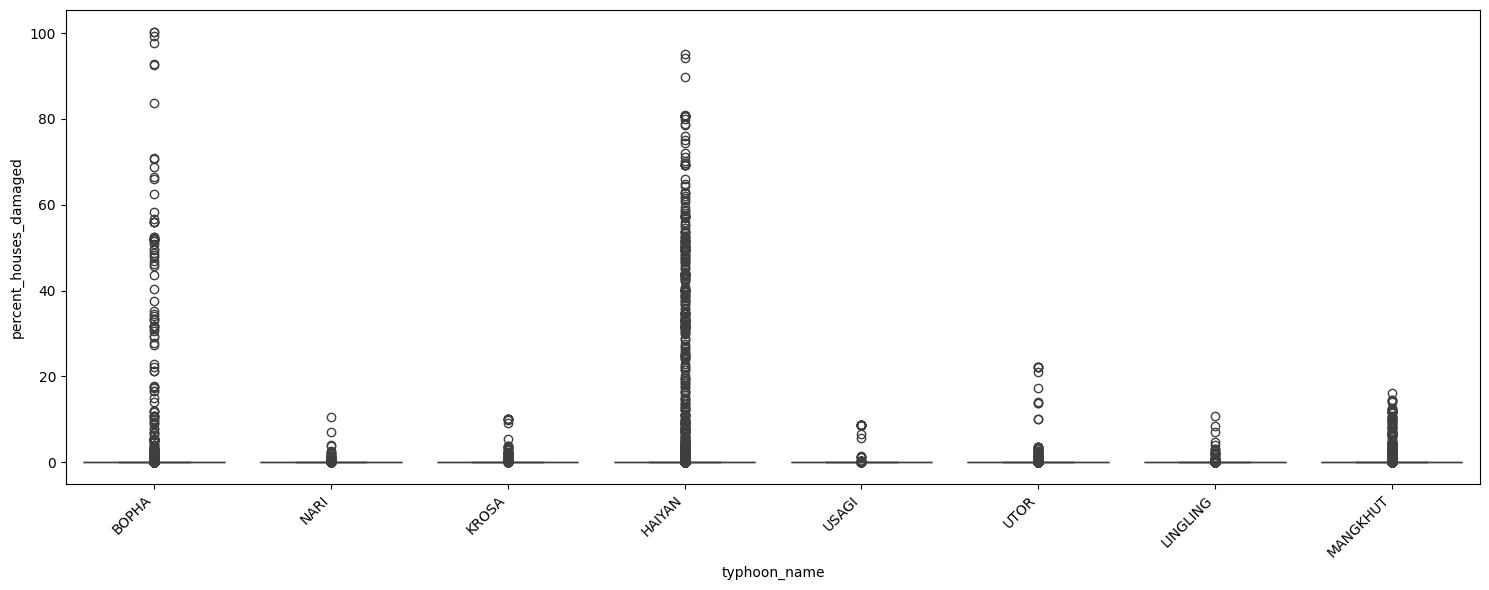

In [ ]:
# checking the stationarity of the target variable, to see if there are any trends over time or by storm that the model could learn from
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='typhoon_name', y='percent_houses_damaged')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

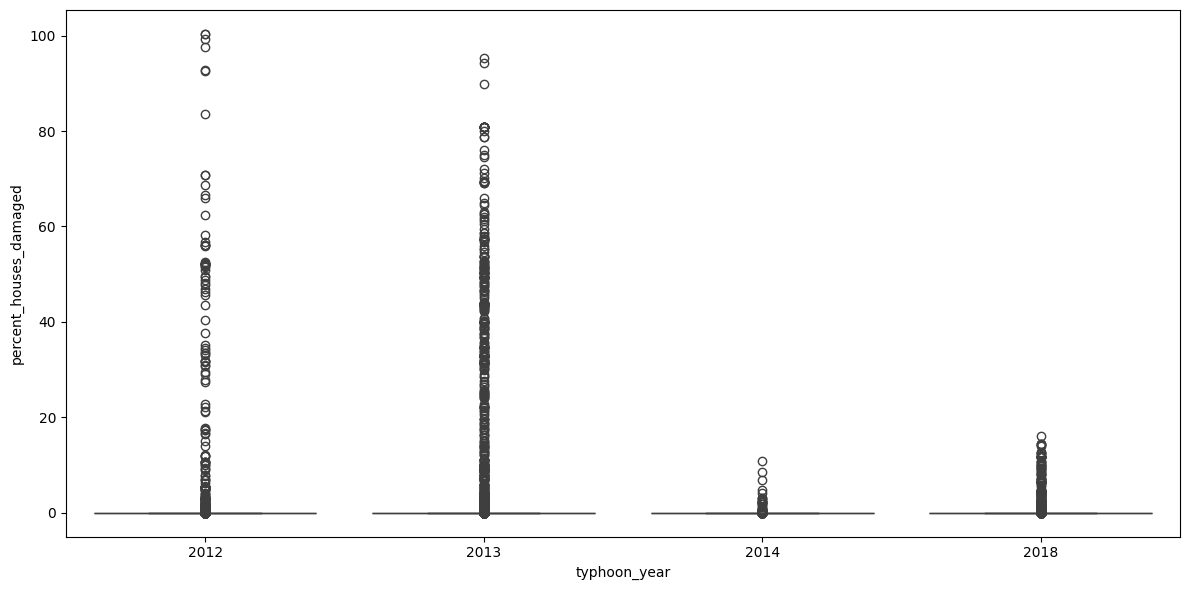

In [222]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='typhoon_year', y='percent_houses_damaged')
plt.tight_layout()
plt.show()

Ok, the other assumptions really won't apply to our data as much since RF is good at handling outliers, but may do a second round and log-transform (or some other transform for the columns with more outliers).

We'll look into correlations in the data, and then maybe get rid of some overly correlated columns before running the baseline model.

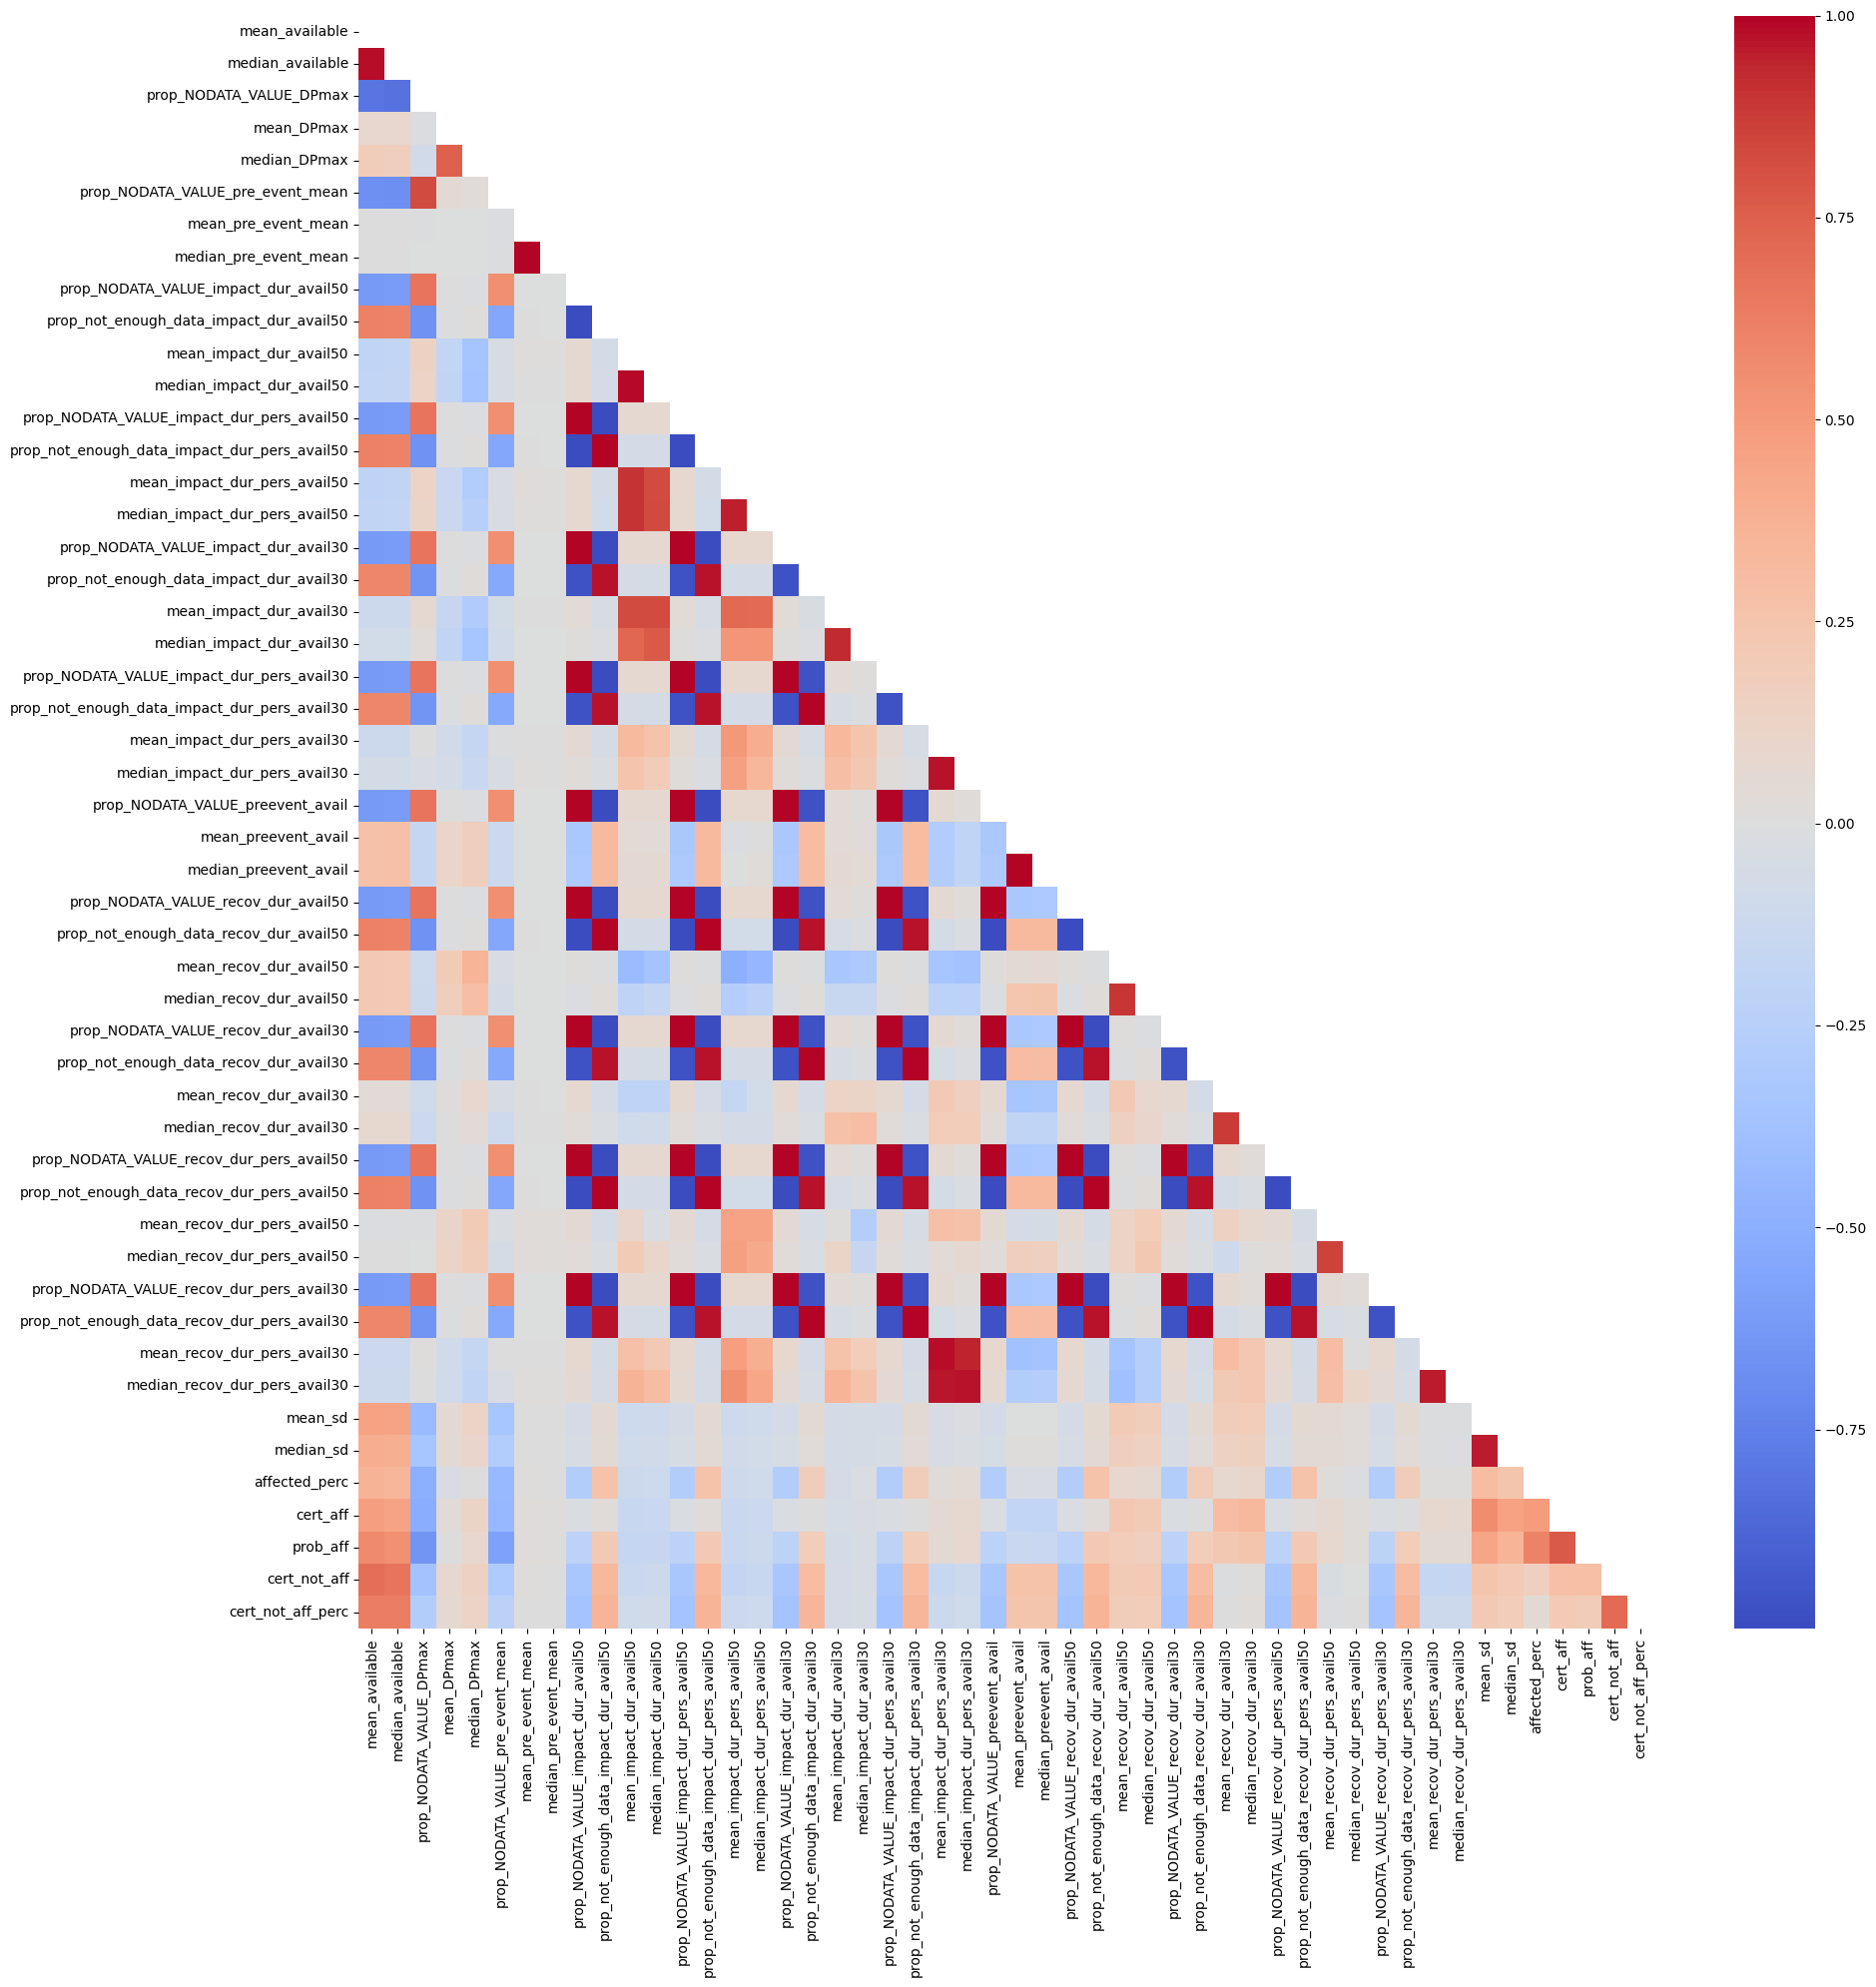

In [70]:
corr = X_train[X_train.columns[3:]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

plt.figure(figsize=(20, 20))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

building a function that removes columns that are too correlated with each other:

In [85]:
cols_to_drop = []
cols_to_skip = []
for i, col in enumerate(X_train.columns):
    for j in X_train.columns[i+1:]:
        if j in cols_to_skip:
            continue  # skip this column as it's already marked for dropping
        corr = X_train[[col, j]].corr().iloc[0, 1]
        col_corr = X_train[col].corr(y_train.squeeze())
        j_corr = X_train[j].corr(y_train.squeeze())
        if abs(corr) > 0.75:
            if abs(col_corr) < abs(j_corr):
                cols_to_drop.append(col)
                break  # drop col and move to next one
            else:
                cols_to_drop.append(j)
                cols_to_skip.append(j)  # skip j in future comparisons
                continue  # keep col and compare it with next features

In [89]:
X_train_simp = X_train.drop(columns=cols_to_drop)
X_test_simp = X_test.drop(columns=cols_to_drop) 

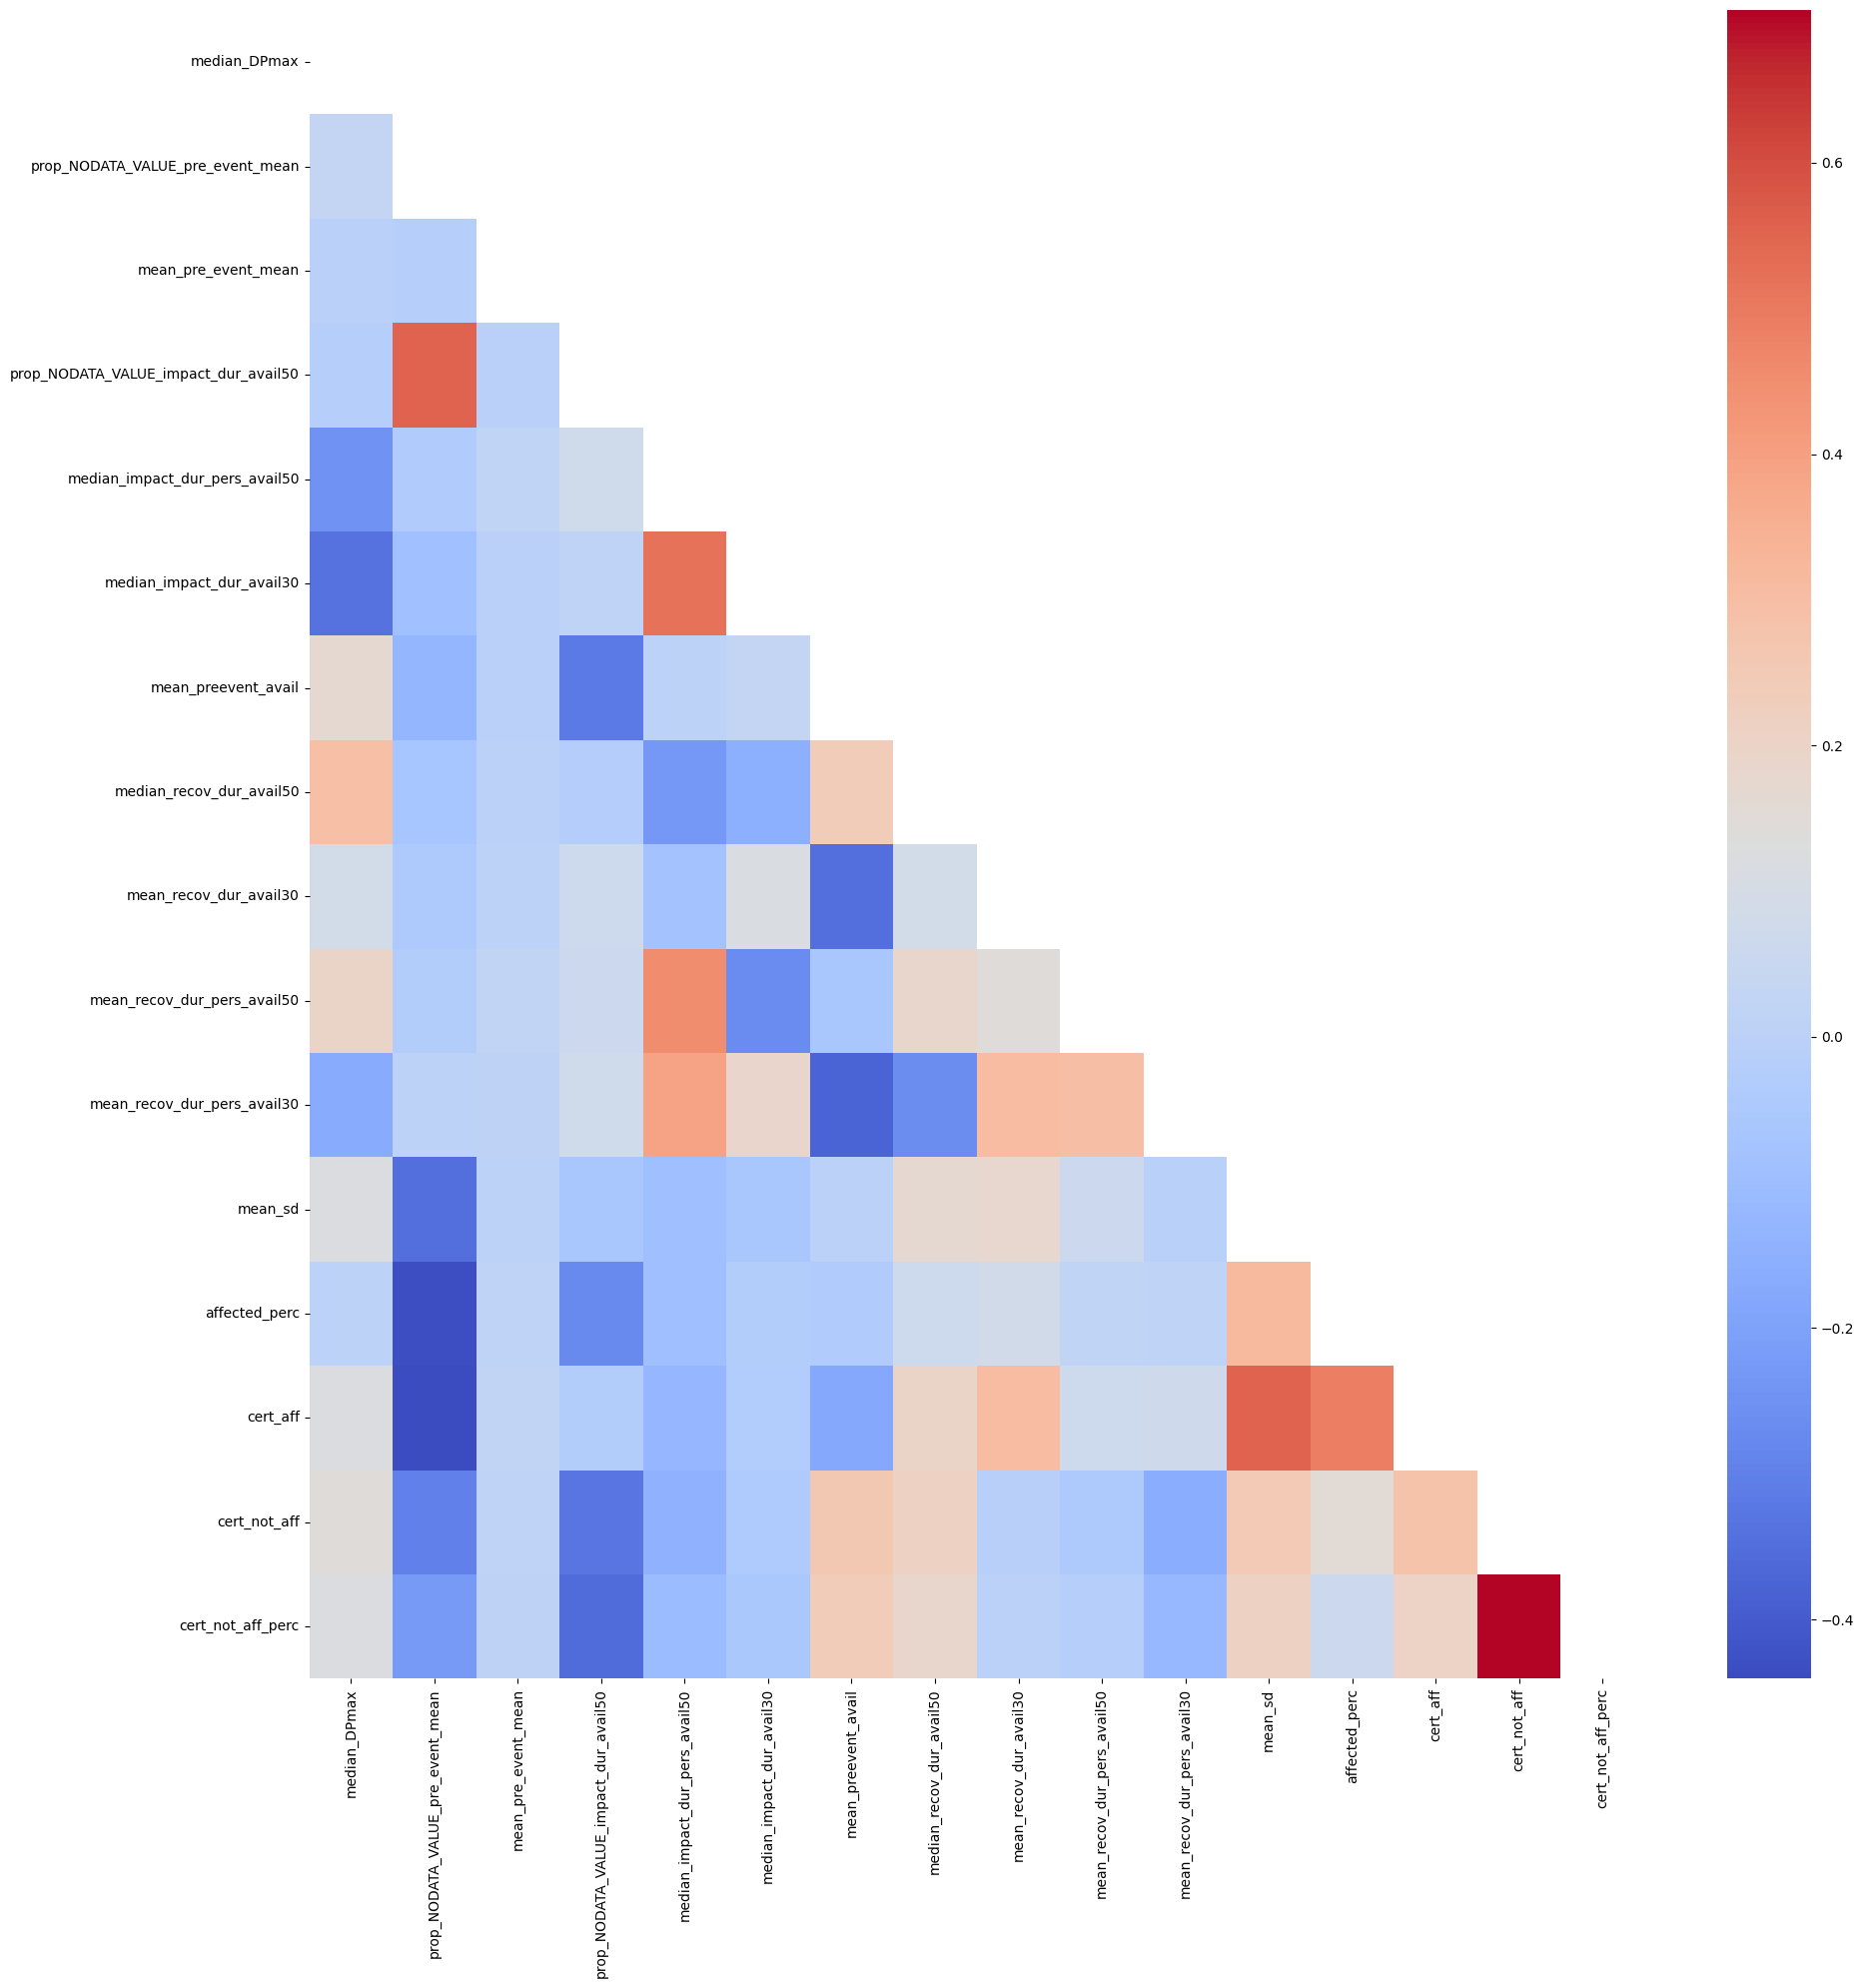

In [90]:
corr = X_train_simp[X_train_simp.columns[3:]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

plt.figure(figsize=(20, 20))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

In [88]:
len(cols_to_drop)

37

In [79]:
X_train.columns[:5]

Index(['grid_point_id', 'majority_aff', 'minority_aff', 'mean_available',
       'median_available'],
      dtype='str')

In [69]:
X_train['prop_NODATA_VALUE_recov_dur_pers_avail30'].value_counts()

prop_NODATA_VALUE_recov_dur_pers_avail30
1.0    17328
0.0     1686
0.5        1
Name: count, dtype: int64

In [ ]:
df_corr = df[df.columns[3:]].drop(columns=['percent_houses_damaged_5years'])

cols_to_drop = drop_correlated_features(df_corr, target_col='percent_houses_damaged')

In [23]:
df_update = df.drop(columns=cols_to_drop)

# len(cols_to_drop)

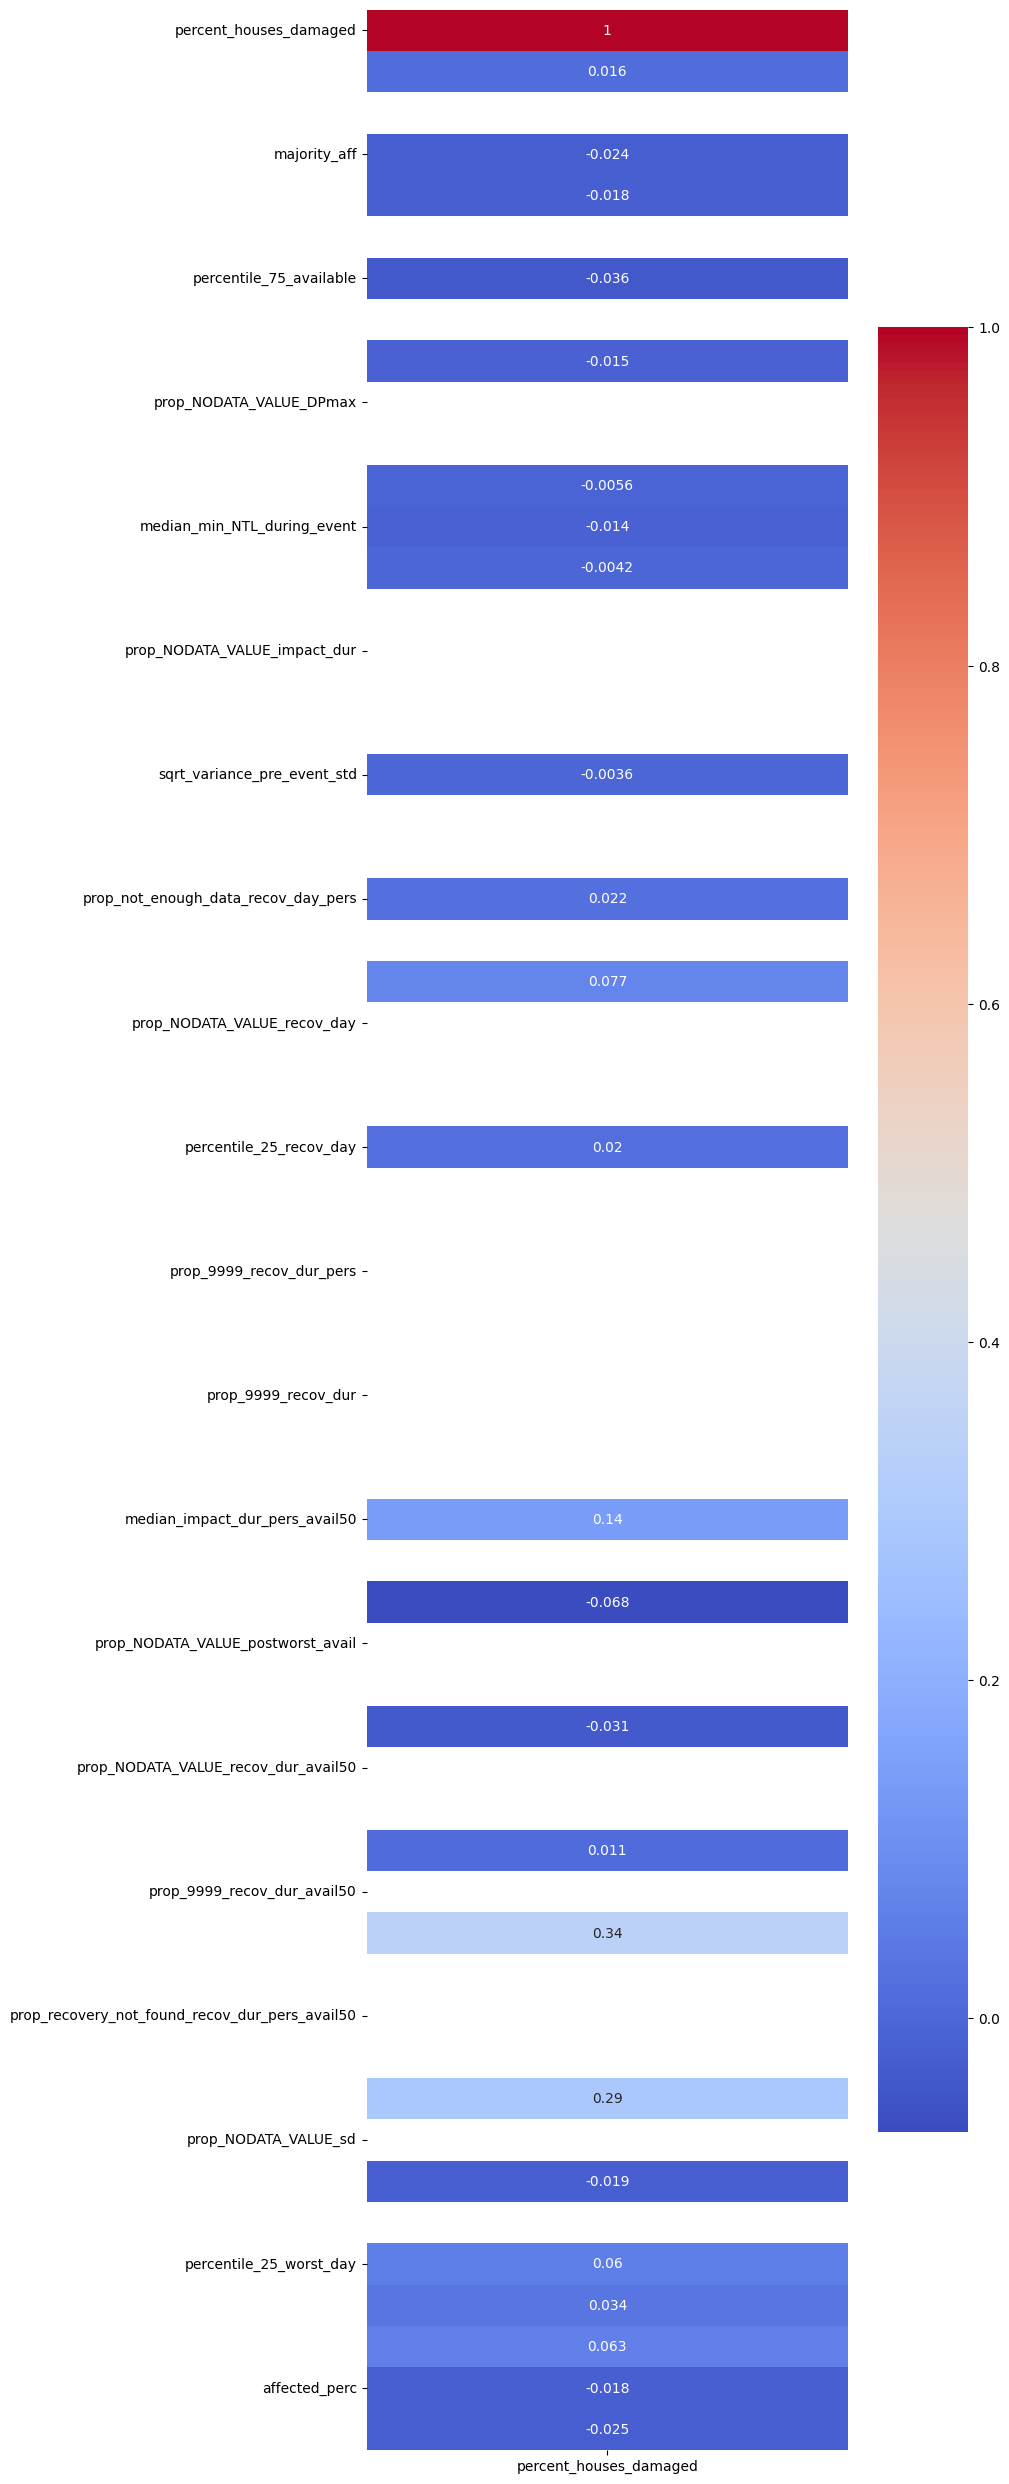

In [28]:
sns.heatmap(df_update[df_update.columns[3:]].corr()[['percent_houses_damaged']], annot=True, cmap='coolwarm')
plt.gcf().set_size_inches(10, 25)  # increase the 20 to make it taller
plt.tight_layout()
plt.show()

### Setting up the model

In [15]:
y.columns[120:]

Index(['percentile_25_sd', 'percentile_75_sd', 'prop_NODATA_VALUE_worst_day',
       'mean_worst_day', 'median_worst_day', 'percentile_25_worst_day',
       'percentile_75_worst_day', 'time_between_start_and_worst',
       'affected_perc', 'for_sure_aff', 'prob_aff'],
      dtype='str')

### Baseline Model

In [244]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np
# Initialize the Random Forest model with default hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
# Cross-validation with R²
r2_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
# Cross-validation with RMSE
rmse_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
std_rmse = np.std(rmse_scores)
# Train and predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
# Test set metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Test Set R²:           {test_r2:.4f}")
print(f"Test Set RMSE:         {test_rmse:.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.6519 ± 0.0693
Cross-validation RMSE: 3.2501 ± 0.2923
Test Set R²:           0.6649
Test Set RMSE:         3.0482


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,       # Use all CPU cores
    verbose=2        # Print progress
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R²:      {grid_search.best_score_:.4f}")

# Use the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"Test Set R²:     {test_r2:.4f}")

In [246]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R²:      {grid_search.best_score_:.4f}")

# Use the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"Test Set R²:     {test_r2:.4f}")

Best Parameters: {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²:      0.6684
Test Set R²:     0.6929


In [247]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

rf_mod =  RandomForestRegressor(
  # Number of trees
  n_estimators = 100, 
  criterion = 'squared_error',
  # Number of features to use in each split
  max_features = 'sqrt',
  oob_score = True,
  random_state = 42
  )

pipe = Pipeline(steps = [
  ("model", rf_mod)
  ])
pipe

# Tune hyper-parameter(s)
tuned_parameters = {
  "model__n_estimators": [50, 100, 150, 200, 250, 300],
  "model__max_features": ['sqrt', 'log2', 1.0], # max_features = 1.0 uses all features,
  "model__max_depth": [None, 10, 20, 30],
  "model__min_samples_split": [2, 5, 10],
  "model__min_samples_leaf": [1, 2, 4]
}
tuned_parameters  

# Set up CV
n_folds = 6
search = GridSearchCV(
  pipe,
  tuned_parameters,
  cv = n_folds, 
  scoring = "neg_root_mean_squared_error",
  n_jobs=-1,       # Use all CPU cores
  # Refit the best model on the whole data set
  refit = True
  )

# Fit CV
search.fit(X_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV R²:      {search.best_score_:.4f}")

# Use the best model on the test set
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"Test Set R²:     {test_r2:.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Best CV R²:      -3.0266
Test Set R²:     0.6940


In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np
# Initialize the Random Forest model with default hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42
)
# Cross-validation with R²
r2_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
# Cross-validation with RMSE
rmse_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
std_rmse = np.std(rmse_scores)
# Train and predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
# Test set metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Test Set R²:           {test_r2:.4f}")
print(f"Test Set RMSE:         {test_rmse:.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.6672 ± 0.0566
Cross-validation RMSE: 3.1893 ± 0.3241
Test Set R²:           0.6937
Test Set RMSE:         2.9141


In [91]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np
# Initialize the Random Forest model with default hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42
)
# Cross-validation with R²
r2_scores = cross_val_score(rf_model, X_train_simp, y_train, cv=5, scoring='r2')
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
# Cross-validation with RMSE
rmse_scores = cross_val_score(rf_model, X_train_simp, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
std_rmse = np.std(rmse_scores)
# Train and predict
rf_model.fit(X_train_simp, y_train)
y_pred = rf_model.predict(X_test_simp)
# Test set metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Test Set R²:           {test_r2:.4f}")
print(f"Test Set RMSE:         {test_rmse:.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.6688 ± 0.0531
Cross-validation RMSE: 3.1859 ± 0.3407
Test Set R²:           0.6963
Test Set RMSE:         2.9018


In [100]:
# Step 1: First tune tree structure
param_grid_1 = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5]       # Minimum loss reduction to split
}

# Step 2: Then tune sampling (after step 1 finds best tree params)
param_grid_2 = {
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 3: Then tune regularization
param_grid_3 = {
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]       # L2
}

fill_gs = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]
}

# {'gamma': 0.5, 'max_depth': 7, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 0.1}

# Base estimator - start with a lower learning rate and more trees
base_xgb = xgb.XGBRegressor(
    learning_rate=0.05,
    n_estimators=500,
    objective='reg:squarederror',
    n_jobs=4,
    random_state=42,
    colsample_bytree=1.0,
    subsample=1.0,
    gamma=0.5,
    max_depth=7,
    min_child_weight=1,
    reg_alpha=0.1,
    reg_lambda=0.1
)

# from first round
# {'gamma': 0.1, 'max_depth': 5, 'min_child_weight': 1}

# {'colsample_bytree': 1.0, 'subsample': 1.0}

# # Run step 1 first
# gsearch1 = GridSearchCV(
#     estimator=base_xgb,
#     param_grid=fill_gs,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     cv=5,
#     verbose=2
# )

base_xgb.fit(X_train_simp, y_train)
y_pred = base_xgb.predict(X_test_simp)
# print(f"Best params: {base_xgb.best_params_}")
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 20.64
R-squared: 0.26


In [102]:
objectives = [
    'reg:squarederror',
    'reg:squaredlogerror', 
    'reg:pseudohubererror',
    'reg:absoluteerror',
    'reg:tweedie'
]

for obj in objectives:
    model = xgb.XGBRegressor(objective=obj, n_estimators=500, learning_rate=0.05, random_state=42)
    model.fit(X_train_simp, y_train)
    y_pred = model.predict(X_test_simp)
    print(f"{obj:<30} R²: {r2_score(y_test, y_pred):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

reg:squarederror               R²: 0.2631  RMSE: 4.5202
reg:squaredlogerror            R²: 0.0770  RMSE: 5.0587
reg:pseudohubererror           R²: 0.0716  RMSE: 5.0736
reg:absoluteerror              R²: 0.0451  RMSE: 5.1454
reg:tweedie                    R²: 0.2555  RMSE: 4.5433


In [103]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(X_train_simp, y_train)

train_r2 = r2_score(y_train, model.predict(X_train_simp))
test_r2 = r2_score(y_test, model.predict(X_test_simp))

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Gap:      {train_r2 - test_r2:.4f}")

Train R²: 0.4006
Test R²:  0.2631
Gap:      0.1376


In [104]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,#removes regularization for now
    reg_lambda=1,#default
    random_state=42
)

model.fit(
    X_train_simp, y_train,
    eval_set=[(X_train_simp, y_train), (X_test_simp, y_test)],
    verbose=100            # Print every 100 rounds to track learning
)

[0]	validation_0-rmse:5.62511	validation_1-rmse:5.25465
[100]	validation_0-rmse:5.05007	validation_1-rmse:4.77031
[200]	validation_0-rmse:4.85165	validation_1-rmse:4.65489
[300]	validation_0-rmse:4.73798	validation_1-rmse:4.60659
[400]	validation_0-rmse:4.66458	validation_1-rmse:4.58501
[500]	validation_0-rmse:4.60645	validation_1-rmse:4.57270
[600]	validation_0-rmse:4.56393	validation_1-rmse:4.57120
[700]	validation_0-rmse:4.52871	validation_1-rmse:4.56638
[800]	validation_0-rmse:4.49951	validation_1-rmse:4.56332
[900]	validation_0-rmse:4.47415	validation_1-rmse:4.55693
[1000]	validation_0-rmse:4.45286	validation_1-rmse:4.56181
[1100]	validation_0-rmse:4.43625	validation_1-rmse:4.56858
[1200]	validation_0-rmse:4.42082	validation_1-rmse:4.56518
[1300]	validation_0-rmse:4.40801	validation_1-rmse:4.56885
[1400]	validation_0-rmse:4.39523	validation_1-rmse:4.57070
[1500]	validation_0-rmse:4.38596	validation_1-rmse:4.57042
[1600]	validation_0-rmse:4.37687	validation_1-rmse:4.57118
[1700]	va

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [105]:
train_r2 = r2_score(y_train, model.predict(X_train_simp))
test_r2 = r2_score(y_test, model.predict(X_test_simp))

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Gap:      {train_r2 - test_r2:.4f}")

Train R²: 0.4042
Test R²:  0.2444
Gap:      0.1598


In [138]:
X_train_simp_2 = X_train_simp.drop(columns=["grid_point_id"])
X_test_simp_2 = X_test_simp.drop(columns=["grid_point_id"])

Saving all the data for use in other notebooks:

In [ ]:
X_train.to_csv('../data/csvs/X_train_data.csv')
X_test.to_csv('../data/csvs/X_test_data.csv')

X_train_simp.to_csv('../data/csvs/simplified_X_train_data.csv')
X_test_simp.to_csv('../data/csvs/simplified_X_test_data.csv')

X_train_simp_2.to_csv('../data/csvs/simplified_X_train_2_data.csv')
X_train_simp_2.to_csv('../data/csvs/simplified_X_train_2_data.csv')

y_test.to_csv('../data/csvs/y_test.csv')
y_train.to_csv('../data/csvs/y_train.csv')


In [139]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error

et_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train_simp_2, y_train)
y_pred_et = et_model.predict(X_test_simp_2)

print(f"Train R²: {r2_score(y_train, et_model.predict(X_train_simp_2)):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_et):.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train R²: 0.1288
Test R²:  0.0563


In [ ]:
# Initialize the Random Forest model with default hyperparameters
rf_model_2 = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42
)
# Cross-validation with R²
r2_scores = cross_val_score(rf_model_2, X_train_simp_2, y_train, cv=5, scoring='r2')
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
# Cross-validation with RMSE
rmse_scores = cross_val_score(rf_model_2, X_train_simp_2, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
std_rmse = np.std(rmse_scores)
# Train and predict
rf_model_2.fit(X_train_simp_2, y_train)
y_pred = rf_model_2.predict(X_test_simp_2)
# Test set metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Test Set R²:           {test_r2:.4f}")
print(f"Test Set RMSE:         {test_rmse:.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Cross-validation R²:   0.0682 ± 0.0160
Cross-validation RMSE: 5.3942 ± 0.6499
Test Set R²:           0.0621
Test Set RMSE:         5.0995


In [137]:
# 2. Are the feature importances reasonable or is one feature dominating?
importances = pd.Series(et_model.feature_importances_, index=X_train_simp.columns)
print(importances.sort_values(ascending=False))

grid_point_id                           0.873412
mean_preevent_avail                     0.019100
median_impact_dur_pers_avail50          0.015815
mean_recov_dur_avail30                  0.013438
mean_recov_dur_pers_avail50             0.012441
mean_recov_dur_pers_avail30             0.010340
mean_pre_event_mean                     0.010313
mean_DPmax                              0.009101
median_DPmax                            0.007381
prop_NODATA_VALUE_pre_event_mean        0.006312
affected_perc                           0.006129
median_recov_dur_avail50                0.005119
minority_aff                            0.004275
median_impact_dur_avail30               0.003294
cert_aff                                0.002417
mean_sd                                 0.000843
prop_NODATA_VALUE_impact_dur_avail50    0.000254
cert_not_aff                            0.000014
cert_not_aff_perc                       0.000001
dtype: float64


In [113]:
y_train.skew().values[0]

np.float64(10.147930571287562)

In [95]:
# Compare which features each model relies on
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train_simp.columns)

print("Top 10 RF features:")
print(rf_importances.nlargest(10))

Top 10 RF features:
grid_point_id                     0.839214
mean_recov_dur_pers_avail50       0.032959
mean_pre_event_mean               0.029695
mean_DPmax                        0.027180
mean_preevent_avail               0.021409
median_recov_dur_avail50          0.011139
median_DPmax                      0.009587
mean_recov_dur_pers_avail30       0.007988
affected_perc                     0.004666
median_impact_dur_pers_avail50    0.003919
dtype: float64


### Hyperparameter Tuning

### Results Comparison

In [ ]:
# print(f"Best Parameters: {search.best_params_}")
# print(f"Best CV R²:      {search.best_score_:.4f}")

# # Use the best model on the test set
# best_model = search.best_estimator_
# y_pred = best_model.predict(X_test)
# test_r2 = r2_score(y_test, y_pred)
print(f"Best Parameters: {search.best_params_}")
print(f"Best CV RMSE:      {search.best_score_:.4f}")
print(f"Test Set R²:     {test_r2:.4f}")

Best Parameters: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Best CV R²:      -3.0266
Test Set R²:     0.6940


Baseline XGBoost model:

since we're going to keep null values in the model, the only inital cleaning we're going to do is dropping the stroms that have no data and removing the storm name columns

In [24]:
X_train.drop(columns=['typhoon_name', 'typhoon_year'], inplace=True)
X_test.drop(columns=['typhoon_name', 'typhoon_year'], inplace=True)

In [50]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Step 1: First tune tree structure
param_grid_1 = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5]       # Minimum loss reduction to split
}

# Step 2: Then tune sampling (after step 1 finds best tree params)
param_grid_2 = {
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 3: Then tune regularization
param_grid_3 = {
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]       # L2
}

# Base estimator - start with a lower learning rate and more trees
base_xgb = xgb.XGBRegressor(
    learning_rate=0.05,
    n_estimators=500,
    booster='gbtree',
    n_jobs=4,
    random_state=42,
    gamma=0.1, 
    max_depth=5,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0
)

# from first round
# {'gamma': 0.1, 'max_depth': 5, 'min_child_weight': 1}

# {'colsample_bytree': 1.0, 'subsample': 1.0}

# Run step 1 first
gsearch1 = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    verbose=2
)

gsearch1.fit(X_train, y_train)
print(f"Best params: {gsearch1.best_params_}")
print(f"Best RMSE:   {-gsearch1.best_score_:.4f}")
print(f"Test R²:     {r2_score(y_test, gsearch1.predict(X_test)):.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ........................reg_alpha=0, reg_lambda=0.1; total time=   1.9s
[CV] END ........................reg_alpha=0, reg_lambda=0.1; total time=   1.9s
[CV] END ........................reg_alpha=0, reg_lambda=0.1; total time=   1.9s
[CV] END ..........................reg_alpha=0, reg_lambda=1; total time=   1.8s
[CV] END ........................reg_alpha=0, reg_lambda=0.1; total time=   1.9s
[CV] END ........................reg_alpha=0, reg_lambda=0.1; total time=   2.0s
[CV] END ..........................reg_alpha=0, reg_lambda=1; total time=   1.9s
[CV] END ..........................reg_alpha=0, reg_lambda=1; total time=   2.1s
[CV] END ..........................reg_alpha=0, reg_lambda=1; total time=   1.7s
[CV] END ..........................reg_alpha=0, reg_lambda=1; total time=   1.7s
[CV] END ..........................reg_alpha=0, reg_lambda=5; total time=   1.7s
[CV] END ..........................reg_alpha=0,

In [ ]:
gsearch1.best_estimator_, gsearch1.best_params_, gsearch1.best_score_

(XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=3,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=140, n_jobs=None, ...),
 {'max_depth': 5, 'max_leaf_nodes': 10, 'min_child_weight': 3},
 np.float64(-5.550545883178711))

In [47]:
y_pred = gsearch1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

R2_sklearn = r2_score(y_test, y_pred)
print(f"R² (Scikit-Learn Calculation): {R2_sklearn}")

Mean Squared Error: 27.18845558166504
R² (Scikit-Learn Calculation): 0.019382774829864502


In [ ]:
# from sklearn.metrics import f1_score

# params = {
#     'max_depth': 5, 
#     'min_child_weight': 1,
#     'learning_rate': 0.1,
#     'objective': 'reg:linear',
#     'scoring': 'neg_root_mean_squared_error',
#     'min_child_weight': 1,
#     'gamma': 0,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'random_state': 42
# }

# # Initialize and train the XGBoost classifier
# model = xgb.XGBRegressor(**params)
# model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the F1 score
# f1 = f1_score(y_test, y_pred)

# print(f"F1 Score: {f1:.2f}")


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [13:00:39] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [13:00:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scoring" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Compare which features each model relies on
# rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

print("Top 10 RF features:")
print(rf_importances.nlargest(10))

print("\nTop 10 XGB features:")
print(xgb_importances.nlargest(10))